# Análise dos picos de tráfego para planejamento de capacidade do PTT/IX

Este notebook analisa a evolução dos picos de tráfego observados no PTT/IX utilizando a base previamente preparada no notebook **00_data_preparation**.

Enquanto o notebook **01_exploratory_analysis_traffic_level** caracteriza o comportamento típico do tráfego por meio de estatísticas descritivas e padrões temporais, este notebook concentra-se nos momentos de maior utilização da rede, que são mais diretamente relacionados ao planejamento da capacidade da infraestrutura de um Internet Exchange (IX).

Neste notebook são realizadas as seguintes análises:

- perfil intradiário do tráfego;
- construção da série de picos diários;
- evolução anual dos picos de tráfego;
- comparação entre o nível típico de tráfego e os picos;
- análise da taxa de crescimento dos picos;
- avaliação da evolução da variabilidade do tráfego.

Todas as análises utilizam a série filtrada gerada no notebook **00_data_preparation**, considerando apenas os anos com completude superior a 95% e o tráfego total (`entrada + saída`), expresso em Gbps.

## 22. Leitura dados

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Diretórios
base_dir = Path.cwd().parent

arquivo_serie_csv = (
    base_dir / "data" / "processed" / "serie_temporal_filtrada_gbps.csv"
)

arquivo_resumo_csv = (
    base_dir / "data" / "processed" / "resumo_anual_filtrado_gbps.csv"
)

# Leitura da série temporal
df_filtrado = pd.read_csv(
    arquivo_serie_csv,
    parse_dates=["datahora"]
)

# Leitura do resumo anual (opcional)
resumo = pd.read_csv(
    arquivo_resumo_csv,
    index_col=0
)

print(f"Série temporal: {df_filtrado.shape[0]:,} observações")
print(f"Período: {df_filtrado['datahora'].min()} a {df_filtrado['datahora'].max()}")

df_filtrado.tail()

Série temporal: 1,897,273 observações
Período: 2008-01-01 00:02:29 a 2026-01-13 17:02:29


,datahora,total_bps,year,total_gbps
1897268,2026-01-13 16:42:29,5.380362e+12,2026,5380.361946
1897269,2026-01-13 16:47:29,5.376236e+12,2026,5376.236384
1897270,2026-01-13 16:52:29,5.377334e+12,2026,5377.333750
1897271,2026-01-13 16:57:29,5.382102e+12,2026,5382.101943
1897272,2026-01-13 17:02:29,5.370277e+12,2026,5370.276506


## Construção da série de picos diários

Embora o notebook anterior tenha caracterizado o comportamento típico do tráfego, o planejamento da capacidade de um Internet Exchange (IX) depende principalmente dos momentos de maior utilização da rede. Por esse motivo, a unidade de análise passa a ser o **dia**, resumindo cada conjunto de medições de 5 minutos por estatísticas representativas dos níveis de utilização diária.

Para cada dia são calculadas as seguintes estatísticas:

- **pico máximo**: maior valor de tráfego observado no dia;
- **percentil 95 diário**: valor abaixo do qual permanecem 95% das medições do dia;
- **média diária**: média das medições de tráfego do dia;
- **desvio padrão**: medida da variabilidade do tráfego ao longo do dia.

A partir dessas estatísticas é construída uma nova série temporal, composta por um registro para cada dia, que servirá de base para analisar a evolução dos picos de tráfego e suas implicações para o planejamento da capacidade da infraestrutura do IX.

In [6]:
df_picos = df_filtrado.copy()
df_picos["data"] = df_picos["datahora"].dt.floor("D")

picos_diarios = (
    df_picos.groupby("data")["total_gbps"]
    .agg(
        pico_max_gbps="max",
        pico_p95_gbps=lambda x: x.quantile(0.95),
        media_gbps="mean",
        desvio_gbps="std",
        n_obs="count"
    )
    .reset_index()
)

picos_diarios = picos_diarios[picos_diarios["n_obs"] > 0].copy()

picos_diarios["ano"] = picos_diarios["data"].dt.year
picos_diarios["weekday"] = picos_diarios["data"].dt.weekday
picos_diarios["is_weekend"] = picos_diarios["weekday"] >= 5
picos_diarios["dia_ano"] = picos_diarios["data"].dt.dayofyear

picos_diarios["fator_pico_sobre_media"] = (
    picos_diarios["pico_max_gbps"] / picos_diarios["media_gbps"]
)

## 23. Resumo anual dos picos

O resumo abaixo permite comparar a evolução dos níveis máximos de utilização da rede ao longo dos anos.

In [7]:
resumo_picos = (
    picos_diarios.groupby("ano")
    .agg(
        media_pico_maximo_gbps=("pico_max_gbps", "mean"),
        mediana_pico_maximo_gbps=("pico_max_gbps", "median"),
        percentil_95_picos_maximos_gbps=("pico_max_gbps", lambda x: x.quantile(0.95)),
        media_percentil_95_diario_gbps=("pico_p95_gbps", "mean"),
        media_fator_pico_sobre_media=("fator_pico_sobre_media", "mean")
    )
    .round(3)
)

resumo_picos["taxa_crescimento_anual_pico"] = (
    resumo_picos["media_pico_maximo_gbps"].pct_change()
).round(3)

resumo_picos["taxa_crescimento_anual_fator"] = (
    resumo_picos["media_fator_pico_sobre_media"].pct_change()
).round(3)

resumo_plot = resumo_picos.reset_index().copy()
resumo_plot["taxa_crescimento_anual_pico"] *= 100
resumo_plot["taxa_crescimento_anual_fator"] *= 100




In [8]:
textos_variaveis = {

    "media_pico_maximo_gbps": (
        """Média anual dos picos máximos diários

É a média dos valores de máximo tráfego de cada dia. Ou seja: pega o valor máximo de cada dia (aprox. 365 valores) e depois calcula a média desses valores.

Como pensar:
Em média, qual foi o pico diário típico nesse ano?

O que indica:
- Crescimento geral da demanda
- Capacidade que a rede precisa suportar

Interpretação:
A média anual dos picos máximos diários apresenta crescimento contínuo ao longo do período, com aceleração mais intensa a partir de 2016 e uma mudança estrutural evidente entre 2020 e 2021. Após esse ponto, o tráfego passa a crescer de forma mais estável, indicando a consolidação de um novo nível de demanda na rede."""
    ),

    "mediana_pico_maximo_gbps": (
        """Mediana dos picos máximos diários

É o valor “do meio” dos picos diários.

Como pensar:
Metade dos dias teve pico menor que isso, metade maior.

Diferença para a média:
Não é afetada por valores extremos.

O que indica:
- Pico típico mais realista
- Se for muito menor que a média, existem picos muito altos (outliers)

Interpretação:
A mediana dos picos máximos diários cresce de forma contínua e estável ao longo do tempo, com aceleração a partir de 2016 e aumento mais intenso entre 2020 e 2021, indicando maior demanda típica da rede. A proximidade entre mediana e média sugere distribuição relativamente equilibrada dos picos, enquanto eventuais diferenças entre elas indicam a presença de picos extremos."""
    ),

    "percentil_95_picos_maximos_gbps": (
        """Percentil 95 dos picos máximos

Exemplo simples:
Imagine um ano com 100 dias:
- pega o máximo de cada dia → 100 valores
- ordena esses valores
- pega o valor que separa os 5 dias mais extremos

Ou seja, estamos olhando os dias mais críticos da rede.

Como pensar:
Entre todos os dias do ano, quão altos são os picos nos dias mais críticos?

O que indica:
- Nível elevado dos picos mais extremos
- Sensível a eventos raros e fora do padrão
- Se cresce, picos muito altos estão se tornando mais frequentes

Interpretação:
O percentil 95 dos picos máximos cresce ao longo do tempo, mas com comportamento mais irregular que as demais métricas. Até 2019, acompanha o crescimento geral da rede; a partir de 2020–2021, apresenta forte aumento seguido de oscilações, indicando que os picos mais extremos se tornaram mais intensos e imprevisíveis."""
    ),

    "media_percentil_95_diario_gbps": (
        """Média do percentil 95 dentro de cada dia

Como pensar:
Em um dia típico, qual é o nível alto de tráfego, sem considerar o pico máximo?

Diferença importante:
- Não depende de eventos extremos
- Representa um nível alto mais estável

O que indica:
- Carga elevada recorrente
- Uso consistente da rede em níveis altos

Resumo:
Captura o nível alto típico de uso diário, não os extremos."""
    ),

    "media_fator_pico_sobre_media": (
        """Fator pico sobre média

Relação entre pico diário e média do dia.

Fórmula:
pico / médi

Como pensar:
O pico é quantas vezes maior que o tráfego médio?

Se pico / média ≈ 1 → tráfego quase constante  
Se pico / média ≈ 2 → pico é o dobro da média  

O que indica:
- Variabilidade do tráfego
- Se o uso é uniforme ou concentrado em picos

Importante:
Essa variável mostra mudança de comportamento, não apenas crescimento."""
    ),

    "taxa_crescimento_anual_pico": (
        """Taxa de crescimento anual dos picos

Quanto a média dos picos cresceu de um ano para o outro.

Como pensar:
Os picos estão crescendo rápido ou devagar?

Exemplos:
1.0 → dobrou (100%)  
0.5 → cresceu 50%  
0.0 → não cresceu  

O que indica:
- Ritmo de crescimento da demanda máxima."""
    ),

    "taxa_crescimento_anual_fator": (
        """Taxa de crescimento anual do fator pico/média

Quanto mudou o fator pico/média de um ano para outro.

Como pensar:
Os picos estão ficando mais intensos em relação ao padrão?

Exemplos:
positivo → mais picos extremos  
negativo → tráfego mais uniforme  

O que indica:
- Mudança na forma do tráfego, não no volume."""
    )
}

In [9]:
titulos = {
    "media_pico_maximo_gbps": "Qual foi o pico diário típico da rede em cada ano?",
    "mediana_pico_maximo_gbps": "O crescimento observado representa a maioria dos dias?",
    "percentil_95_picos_maximos_gbps": "Como evoluíram os dias mais críticos da rede?",
    "media_percentil_95_diario_gbps": "Qual foi o nível alto típico de tráfego ao longo dos dias?",
    "media_fator_pico_sobre_media": "Os picos ficaram mais intensos em relação ao tráfego médio?",
    "taxa_crescimento_anual_pico": "Em quais períodos os picos cresceram mais rapidamente?",
    "taxa_crescimento_anual_fator": "A intensidade dos picos está aumentando ao longo do tempo?"
}

In [10]:
ylabels = {
    "media_pico_maximo_gbps": "Média dos picos diários (Gbps)",
    "mediana_pico_maximo_gbps": "Mediana dos picos diários (Gbps)",
    "percentil_95_picos_maximos_gbps": "Percentil 95 dos picos diários (Gbps)",
    "media_percentil_95_diario_gbps": "Percentil 95 dos picos diários (Gbps)",
    "media_fator_pico_sobre_media": "Fator pico/média",
    "taxa_crescimento_anual_pico": "Taxa de crescimento anual",
    "taxa_crescimento_anual_fator": "Taxa de crescimento anual"
}

In [11]:
import matplotlib.pyplot as plt

def plot_com_caixa(
    df,
    coluna,
    titulo,
    texto,
    ylabel="Gbps",
    xlabel="Ano",
    coluna_x="ano",
    anos_referencia=(2020, 2021),
    figsize=(15, 5)
):
    fig, ax = plt.subplots(
        1, 2,
        figsize=figsize,
        gridspec_kw={"width_ratios": [3, 1.3]}
    )

    # gráfico
    ax[0].plot(
        df[coluna_x],
        df[coluna],
        marker="o",
        linewidth=2
    )

    for ano in anos_referencia:
        ax[0].axvline(ano, linestyle="--", alpha=0.5)

    ax[0].set_title(titulo)
    ax[0].set_xlabel(xlabel)
    ax[0].set_ylabel(ylabel)
    ax[0].grid(alpha=0.3)

    # linha zero para taxas de crescimento
    if "taxa_crescimento" in coluna:
        ax[0].axhline(0, linestyle="--", alpha=0.6)

    # caixa lateral
    ax[1].axis("off")
    ax[1].text(
        0,
        1,
        texto,
        fontsize=10,
        va="top",
        wrap=True
    )

    plt.tight_layout()
    plt.show()

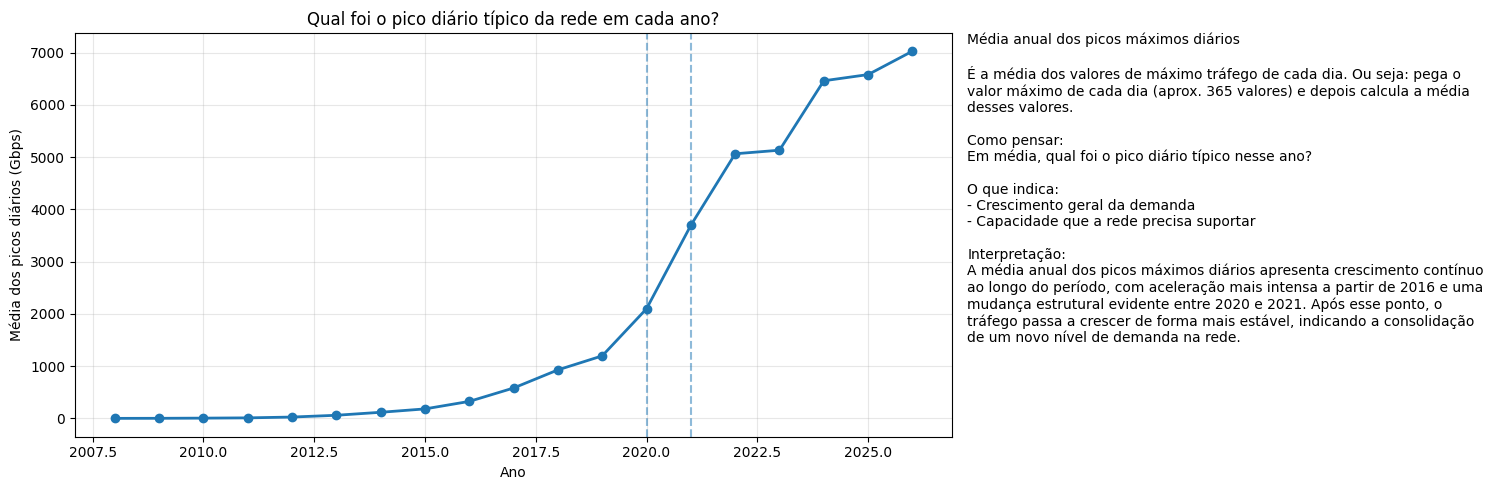

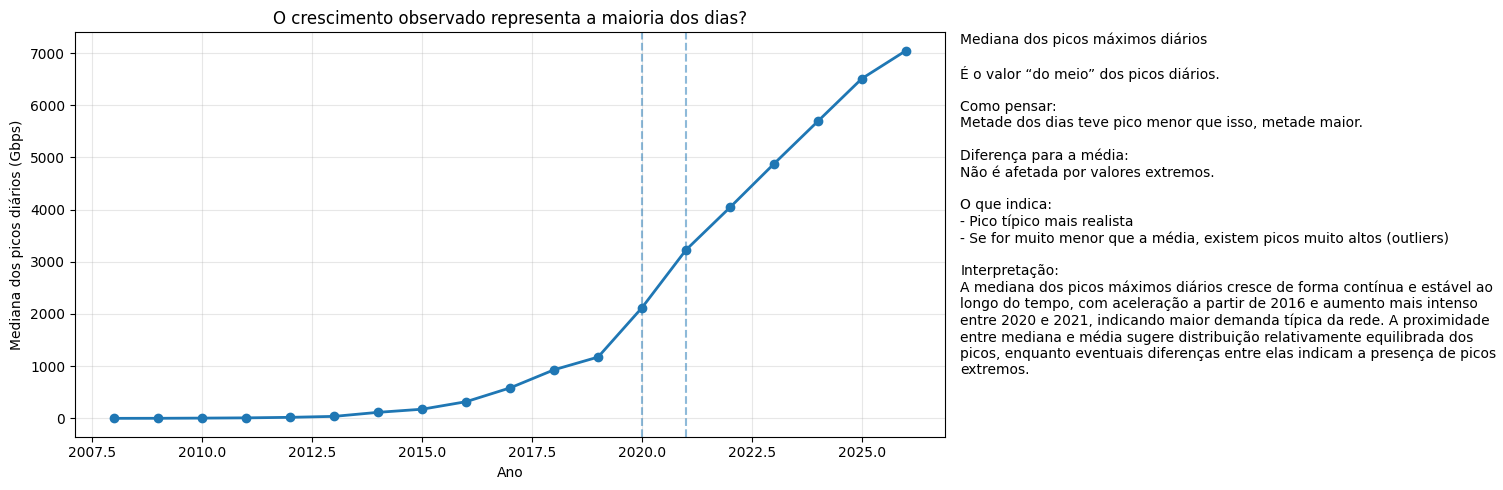

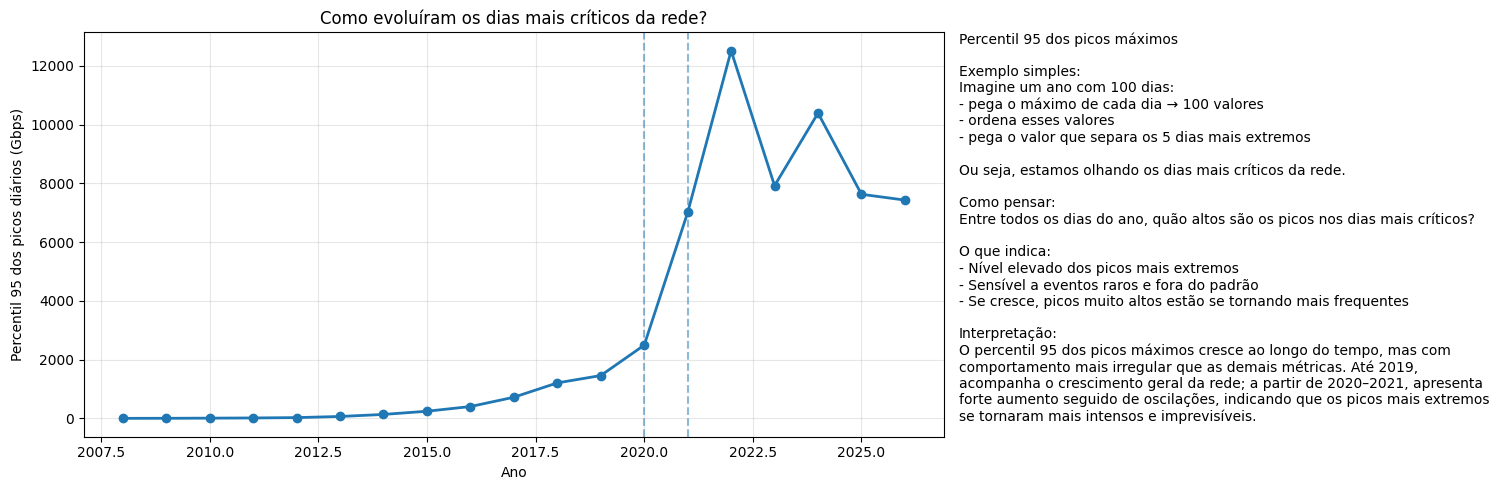

In [12]:
# Variáveis de nível / distribuição dos picos
variaveis_nivel = [
    "media_pico_maximo_gbps",
    "mediana_pico_maximo_gbps",
    "percentil_95_picos_maximos_gbps",
   
    
]

for variavel in variaveis_nivel:
    plot_com_caixa(
        df=resumo_plot,
        coluna=variavel,
        titulo=titulos[variavel],
        texto=textos_variaveis[variavel],
        ylabel=ylabels[variavel]
    )

**Resumo e interpretação integrada**

Considerando que:

Mediana dos picos → comportamento típico

Média dos picos → nível geral (com influência de extremos)

Percentil 95 dos picos → comportamento dos extremos

Leitura integrada

1. Crescimento estrutural da rede
Mediana ↑ continuamente
Média ↑ continuamente

Significa: o uso típico da rede está aumentando de forma consistente

2. Intensificação dos picos
Média cresce mais que a mediana em alguns períodos
P95 cresce muito mais
Significa: Os picos estão ficando mais intensos que o “normal”

3. Aumento da variabilidade (ponto mais importante)
Mediana → suave
P95 → irregular e com saltos

Significa: A rede não só cresceu — ela ficou mais imprevisível

O crescimento do tráfego foi acompanhado por uma mudança na sua distribuição: além do aumento do nível típico de uso, houve intensificação e maior variabilidade dos picos extremos.




A análise conjunta das métricas indica que o crescimento do tráfego não ocorreu apenas no nível médio, mas foi acompanhado por maior variabilidade e intensificação dos picos extremos. Do ponto de vista de planejamento de rede, o percentil 95 dos picos máximos se mostra a métrica mais relevante, pois captura os níveis críticos de demanda que devem ser suportados para garantir a estabilidade do sistema.



## Taxas de crescimento

In [13]:
texto_comparacao_pico_nivel = """
Comparação entre pico e nível de tráfego

O que este gráfico mostra:
Compara a média anual dos picos máximos diários com o nível alto típico de tráfego dentro dos dias.

Como pensar:
A linha dos picos mostra os momentos de maior demanda.
A linha do p95 diário médio mostra um nível alto, mas mais estável, do tráfego diário.

O que observar:
- Se as linhas crescem juntas, o tráfego aumenta de forma proporcional
- Se a linha dos picos se afasta, os picos estão crescendo mais que o nível típico
- Maior distância entre as linhas indica maior variabilidade

Interpretação:
O gráfico ajuda a mostrar se o crescimento da rede é apenas aumento geral de tráfego ou se também há intensificação dos picos.

Resumo:
Quando os picos crescem mais rápido que o nível típico, a rede fica mais sujeita a momentos críticos de alta demanda.
"""

In [14]:
texto_comparacao_pico_nivel = """
Comparação entre pico e nível de tráfego

O que este gráfico mostra:
Compara a média anual dos picos máximos diários com o nível alto típico de tráfego dentro dos dias.

Linha laranaja :Para cada dia pega os 5% maiores valores daquele dia calcula o percentil 95 daquele dia
depois faz a média desses valores ao longo do ano

Linha azul: Pega o valor máximo de cada dia e depois calcula a média anual desses valores

Como pensar:
A linha dos picos mostra os momentos de maior demanda.
A linha do p95 diário médio mostra um nível alto, mas mais estável, do tráfego diário.

O que observar:
- Se as linhas crescem juntas, o tráfego aumenta de forma proporcional
- Se a linha dos picos se afasta, os picos estão crescendo mais que o nível típico
- Maior distância entre as linhas indica maior variabilidade

Interpretação:
O gráfico ajuda a mostrar se o crescimento da rede é apenas aumento geral de tráfego ou se também há intensificação dos picos.

Resumo:
Quando os picos crescem mais rápido que o nível típico, a rede fica mais sujeita a momentos críticos de alta demanda.
"""

In [15]:
import matplotlib.pyplot as plt

def plot_comparacao_com_caixa(
    df,
    coluna_1,
    coluna_2,
    titulo,
    texto,
    label_1,
    label_2,
    ylabel="Gbps",
    xlabel="Ano",
    coluna_x="ano",
    anos_referencia=(2020, 2021),
    figsize=(15, 5)
):
    fig, ax = plt.subplots(
        1, 2,
        figsize=figsize,
        gridspec_kw={"width_ratios": [3, 1.2]}
    )

    ax[0].plot(
        df[coluna_x],
        df[coluna_1],
        marker="o",
        linewidth=2,
        label=label_1
    )

    ax[0].plot(
        df[coluna_x],
        df[coluna_2],
        marker="o",
        linewidth=2,
        label=label_2
    )

    for ano in anos_referencia:
        ax[0].axvline(ano, linestyle="--", alpha=0.5)

    ax[0].set_title(titulo)
    ax[0].set_xlabel(xlabel)
    ax[0].set_ylabel(ylabel)
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    ax[1].axis("off")
    ax[1].text(
        0,
        1,
        texto,
        fontsize=10,
        va="top",
        wrap=True
    )

    plt.tight_layout()
    plt.show()

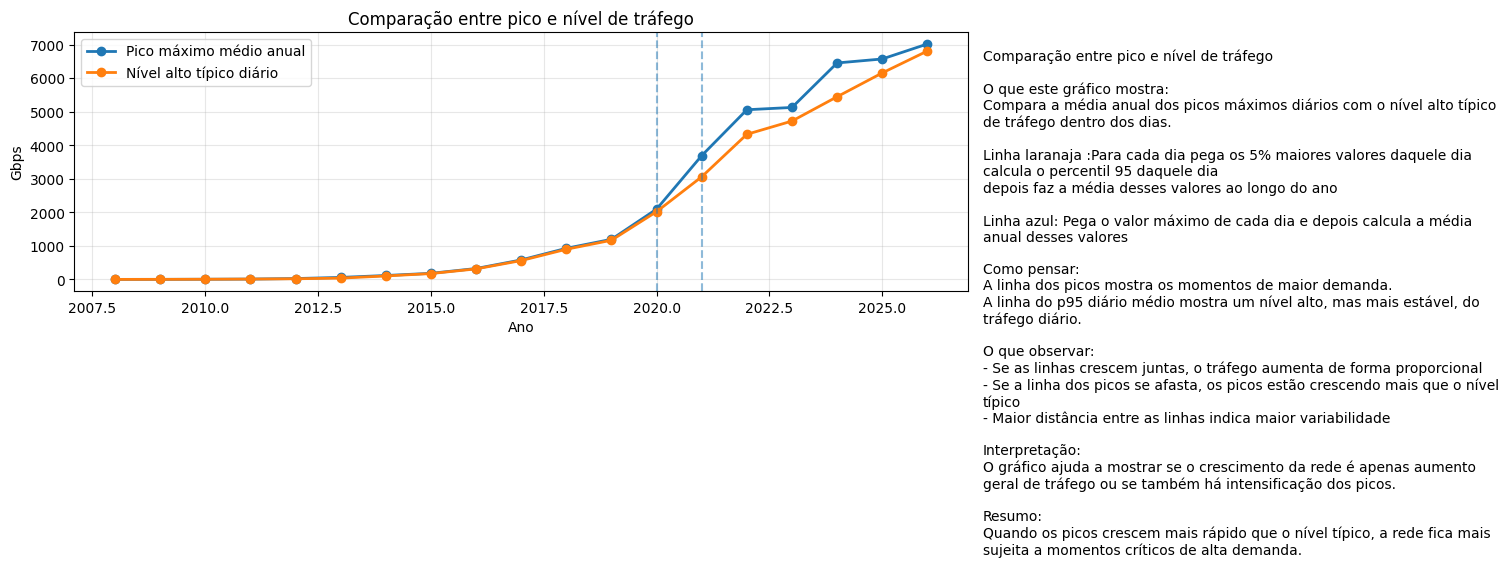

In [16]:
plot_comparacao_com_caixa(
    df=resumo_plot,
    coluna_1="media_pico_maximo_gbps",
    coluna_2="media_percentil_95_diario_gbps",
    titulo="Comparação entre pico e nível de tráfego",
    texto=texto_comparacao_pico_nivel,
    label_1="Pico máximo médio anual",
    label_2="Nível alto típico diário"
)

## 26. Variação intra-anual dos picos diários

 O objetivo é verificar se existem períodos do ano em que os picos de tráfego tendem a ser mais elevados ou mais baixos.

Essa análise ajuda a identificar possíveis padrões sazonais anuais antes de avançar para análises espectrais, como Fourier.

In [17]:
# Normalização intra-anual dos picos
# Objetivo: remover o efeito do crescimento de longo prazo da rede

picos_diarios_norm = picos_diarios.copy()

# referência anual: mediana dos picos de cada ano
referencia_anual = (
    picos_diarios_norm
    .groupby("ano")["pico_max_gbps"]
    .transform("median")
)

# índice relativo ao ano
picos_diarios_norm["indice_pico_relativo"] = (
    picos_diarios_norm["pico_max_gbps"] / referencia_anual
)

picos_diarios_norm

,data,pico_max_gbps,pico_p95_gbps,media_gbps,desvio_gbps,n_obs,ano,weekday,is_weekend,dia_ano,fator_pico_sobre_media,indice_pico_relativo
9,2008-01-10,0.520317,0.386831,0.233370,0.123246,170,2008,3,False,10,2.229583,0.470037
10,2008-01-11,0.680078,0.665699,0.384466,0.208771,288,2008,4,False,11,1.768889,0.614359
11,2008-01-12,0.675091,0.648432,0.351809,0.210455,288,2008,5,True,12,1.918914,0.609854
12,2008-01-13,0.327326,0.318753,0.221142,0.093459,288,2008,6,True,13,1.480167,0.295696
13,2008-01-14,0.595106,0.363337,0.238256,0.106753,288,2008,0,False,14,2.497758,0.537599
...,...,...,...,...,...,...,...,...,...,...,...,...
6583,2026-01-09,7043.828566,6712.683891,4307.056469,1682.696563,285,2026,4,False,9,1.635416,1.000000
6584,2026-01-10,7005.276915,6473.503225,4305.593678,1683.513417,285,2026,5,True,10,1.627018,0.994527
6585,2026-01-11,7024.939284,6826.438854,4499.113847,1849.773122,286,2026,6,True,11,1.561405,0.997318
6586,2026-01-12,7389.668175,7218.623601,4368.078070,1843.272899,287,2026,0,False,12,1.691744,1.049098


In [18]:
sazonalidade_anual_norm = (
    picos_diarios_norm
    .groupby("dia_ano")["indice_pico_relativo"]
    .agg(
        media_indice="mean",
        mediana_indice="median",
        p25_indice=lambda x: x.quantile(0.25),
        p75_indice=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

sazonalidade_anual_norm

,dia_ano,media_indice,mediana_indice,p25_indice,p75_indice
0,1,0.661775,0.604860,0.524323,0.665896
1,2,0.708318,0.708808,0.590874,0.814238
2,3,0.744159,0.735776,0.696745,0.875977
3,4,0.791227,0.749851,0.693010,0.837776
4,5,0.747310,0.724561,0.670805,0.807253
...,...,...,...,...,...
361,362,1.222775,1.180255,1.054699,1.395366
362,363,1.229725,1.173545,1.042094,1.430853
363,364,1.196201,1.196738,1.019095,1.342069
364,365,1.141527,1.140264,1.034654,1.261256


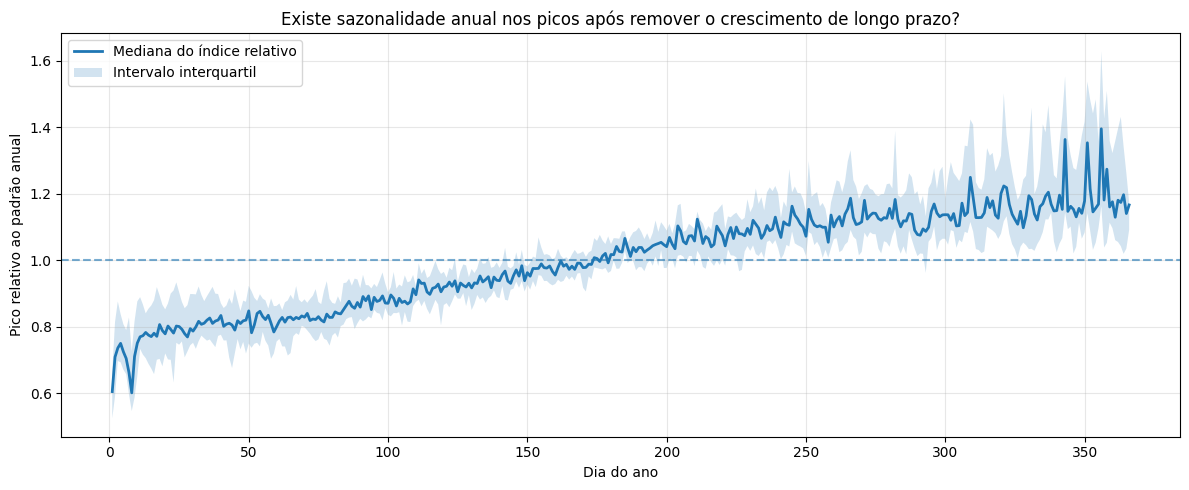

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    sazonalidade_anual_norm["dia_ano"],
    sazonalidade_anual_norm["mediana_indice"],
    linewidth=2,
    label="Mediana do índice relativo"
)

plt.fill_between(
    sazonalidade_anual_norm["dia_ano"],
    sazonalidade_anual_norm["p25_indice"],
    sazonalidade_anual_norm["p75_indice"],
    alpha=0.2,
    label="Intervalo interquartil"
)

plt.axhline(1, linestyle="--", alpha=0.6)

plt.xlabel("Dia do ano")
plt.ylabel("Pico relativo ao padrão anual")
plt.title("Existe sazonalidade anual nos picos após remover o crescimento de longo prazo?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

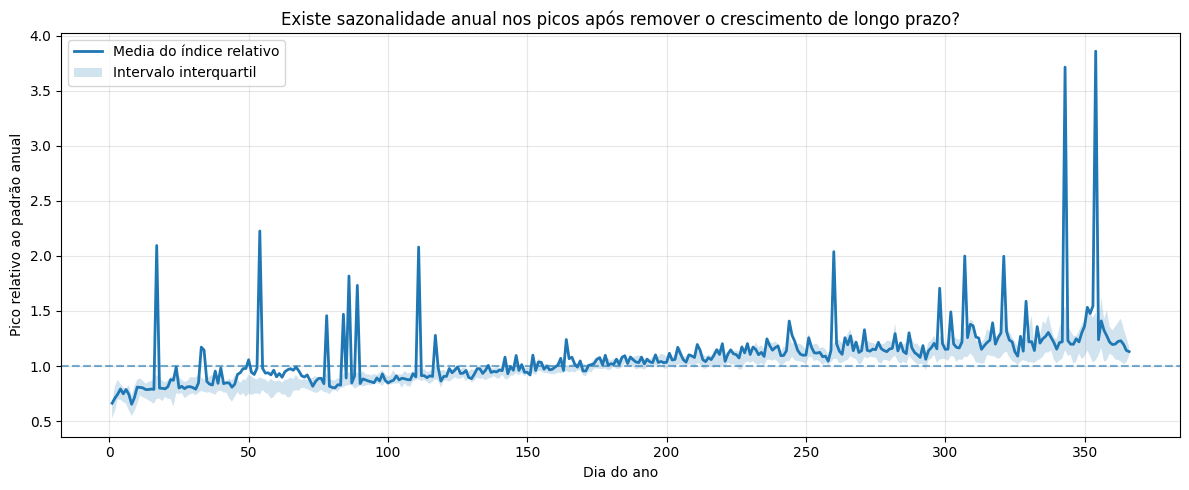

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(
    sazonalidade_anual_norm["dia_ano"],
    sazonalidade_anual_norm["media_indice"],
    linewidth=2,
    label="Media do índice relativo"
)

plt.fill_between(
    sazonalidade_anual_norm["dia_ano"],
    sazonalidade_anual_norm["p25_indice"],
    sazonalidade_anual_norm["p75_indice"],
    alpha=0.2,
    label="Intervalo interquartil"
)

plt.axhline(1, linestyle="--", alpha=0.6)

plt.xlabel("Dia do ano")
plt.ylabel("Pico relativo ao padrão anual")
plt.title("Existe sazonalidade anual nos picos após remover o crescimento de longo prazo?")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Exploração breve de outliers

Essa etapa tem como objetivo entender os picos no gráfico acima (média do pico relativo) ao longo do ano.

A inspeção da sazonalidade anual mostrou que os anos iniciais da série (especialmente 2012–2013) apresentam eventos extremos que influenciam fortemente estatísticas agregadas por dia do ano. Como a etapa de modelagem utilizará apenas o período recente da série, optou-se por não aprofundar esta análise neste momento.

In [21]:
diagnostico = (
    picos_diarios_norm
    .groupby("dia_ano")
    .agg(
        n=("indice_pico_relativo", "count"),
        media=("indice_pico_relativo", "mean"),
        mediana=("indice_pico_relativo", "median"),
        q1=("indice_pico_relativo", lambda x: x.quantile(0.25)),
        q3=("indice_pico_relativo", lambda x: x.quantile(0.75)),
        max=("indice_pico_relativo", "max")
    )
)

diagnostico.loc[diagnostico["max"] > 3]

,n,media,mediana,q1,q3,max
dia_ano,,,,,,
17,18,2.094868,0.770963,0.700523,0.918962,24.430994
24,18,0.990734,0.801893,0.751688,0.933238,4.010699
33,18,1.171869,0.807166,0.773187,0.895596,6.721844
34,18,1.143376,0.810558,0.765140,0.876914,6.266470
47,18,0.939588,0.809432,0.731776,0.847137,3.186287
48,18,0.976503,0.817687,0.754206,0.878277,3.172361
49,18,0.977531,0.819762,0.719273,0.874922,3.212991
50,18,1.056983,0.847487,0.749370,0.922612,3.227453
51,18,0.942743,0.781704,0.736531,0.906725,3.114866


In [22]:
outliers = picos_diarios_norm[
    picos_diarios_norm["indice_pico_relativo"] > 10
]

outliers[
    ["ano", "data", "dia_ano", "pico_max_gbps", "indice_pico_relativo"]
].sort_values("indice_pico_relativo", ascending=False)

,ano,data,dia_ano,pico_max_gbps,indice_pico_relativo
1814,2012,2012-12-19,354,1001.530311,48.875288
1803,2012,2012-12-08,343,874.902049,42.695752
1843,2013,2013-01-17,17,950.902309,24.430994
1880,2013,2013-02-23,54,917.253730,23.566480
1937,2013,2013-04-21,111,837.312077,21.512584
1912,2013,2013-03-27,86,703.914163,18.085268
2086,2013,2013-09-17,260,685.796072,17.619770
1915,2013,2013-03-30,89,654.631585,16.819078
2133,2013,2013-11-03,307,616.604497,15.842070
2147,2013,2013-11-17,321,547.580810,14.068683


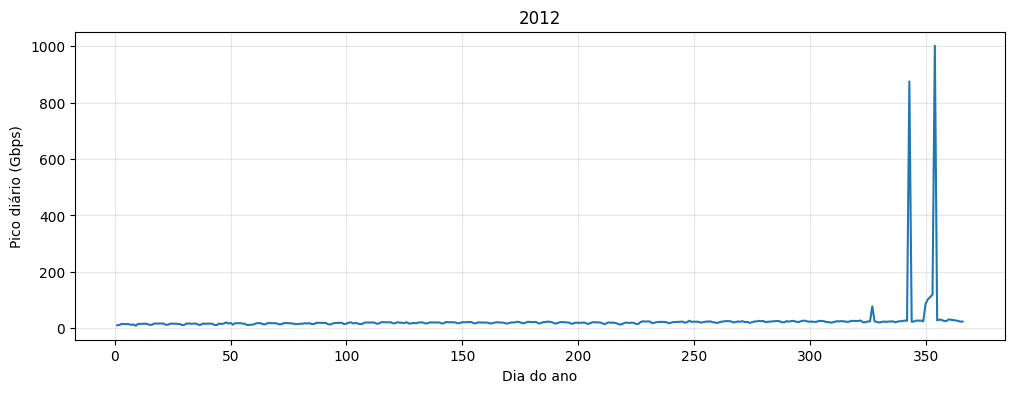

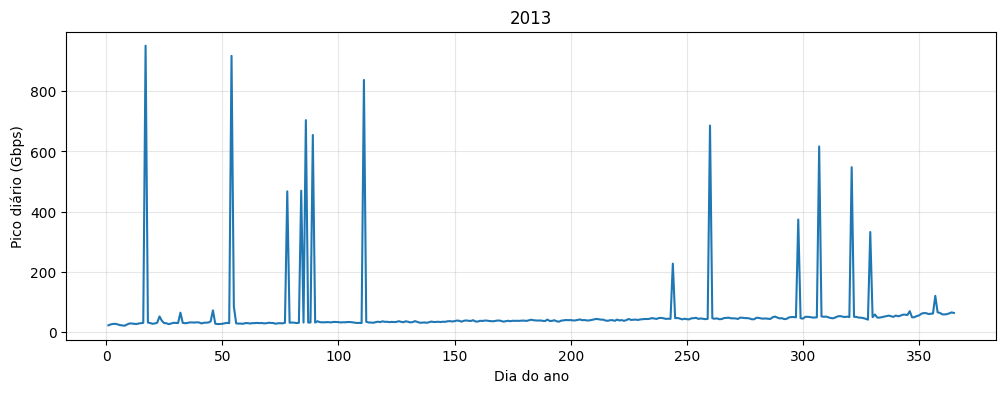

In [23]:
for ano in [2012, 2013]:
    plt.figure(figsize=(12,4))

    df = picos_diarios[picos_diarios["ano"] == ano]

    plt.plot(df["dia_ano"], df["pico_max_gbps"])
    plt.title(str(ano))
    plt.xlabel("Dia do ano")
    plt.ylabel("Pico diário (Gbps)")
    plt.grid(alpha=0.3)

    plt.show()

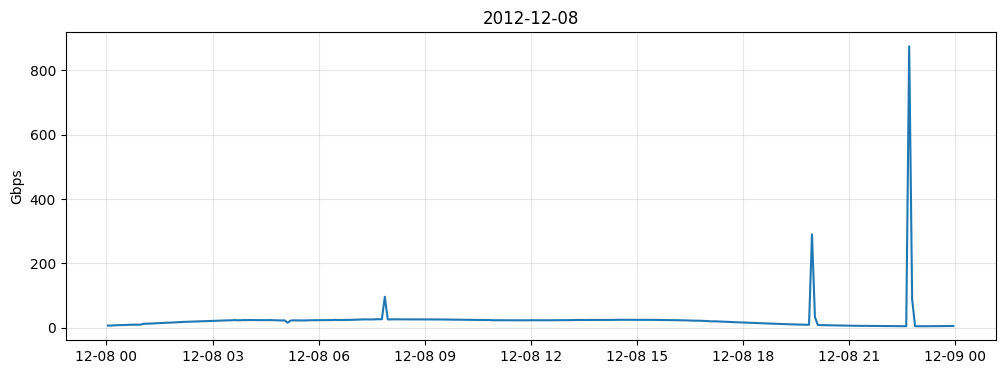

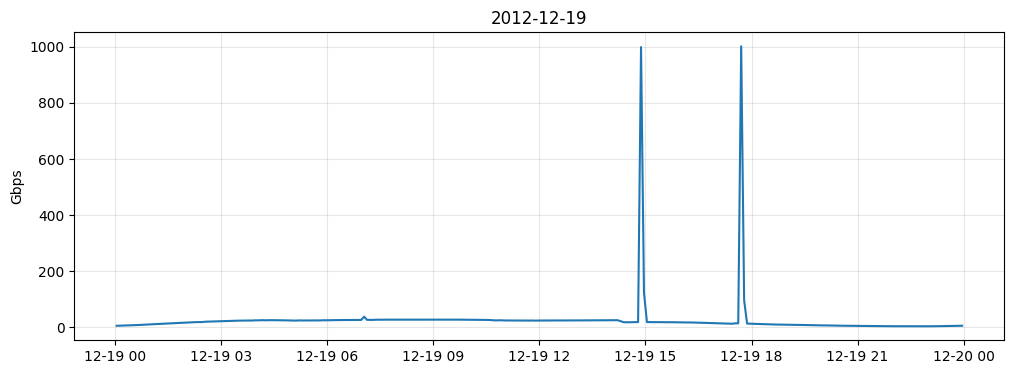

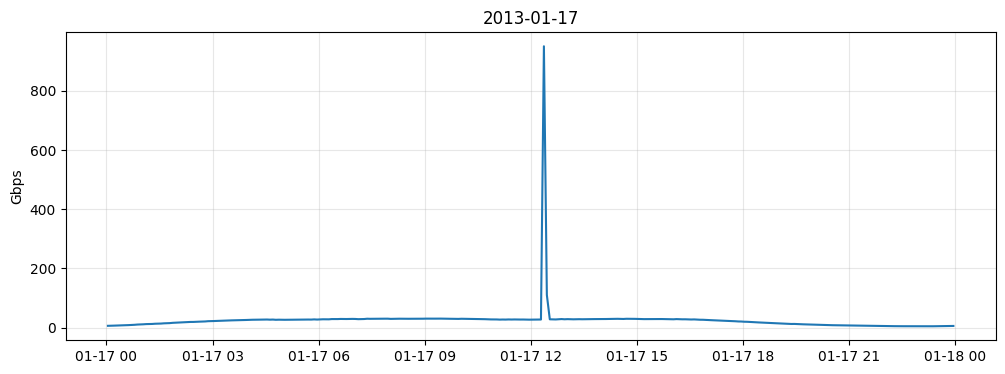

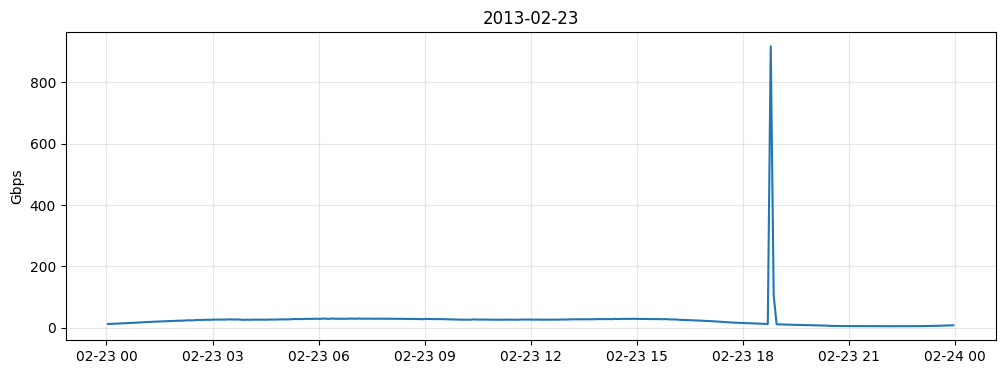

In [24]:
dias_extremos = [
    "2012-12-08",
    "2012-12-19",
    "2013-01-17",
    "2013-02-23"
]

for dia in dias_extremos:
    plt.figure(figsize=(12,4))

    temp = df_filtrado[
        df_filtrado["datahora"].dt.strftime("%Y-%m-%d") == dia
    ]

    plt.plot(temp["datahora"], temp["total_gbps"])

    plt.title(dia)
    plt.ylabel("Gbps")
    plt.grid(alpha=.3)

    plt.show()

In [25]:
mapa_dias = {
    0: "Seg",
    1: "Ter",
    2: "Qua",
    3: "Qui",
    4: "Sex",
    5: "Sáb",
    6: "Dom"
}

resumo_weekday_picos = (
    picos_diarios.groupby("weekday")
    .agg(
        media_pico_max_gbps=("pico_max_gbps", "mean"),
        media_pico_p95_gbps=("pico_p95_gbps", "mean"),
        media_fator_pico_sobre_media=("fator_pico_sobre_media", "mean")
    )
    .reset_index()
)

resumo_weekday_picos["dia"] = resumo_weekday_picos["weekday"].map(mapa_dias)
resumo_weekday_picos = resumo_weekday_picos.round(3)

resumo_weekday_picos

,weekday,media_pico_max_gbps,media_pico_p95_gbps,media_fator_pico_sobre_media,dia
0,0,1824.989,1648.113,1.782,Seg
1,1,1858.645,1659.802,1.774,Ter
2,2,1861.803,1639.740,1.799,Qua
3,3,1785.165,1619.474,1.727,Qui
4,4,1757.286,1613.782,1.685,Sex
5,5,1814.655,1596.482,1.792,Sáb
6,6,1811.213,1609.418,1.693,Dom


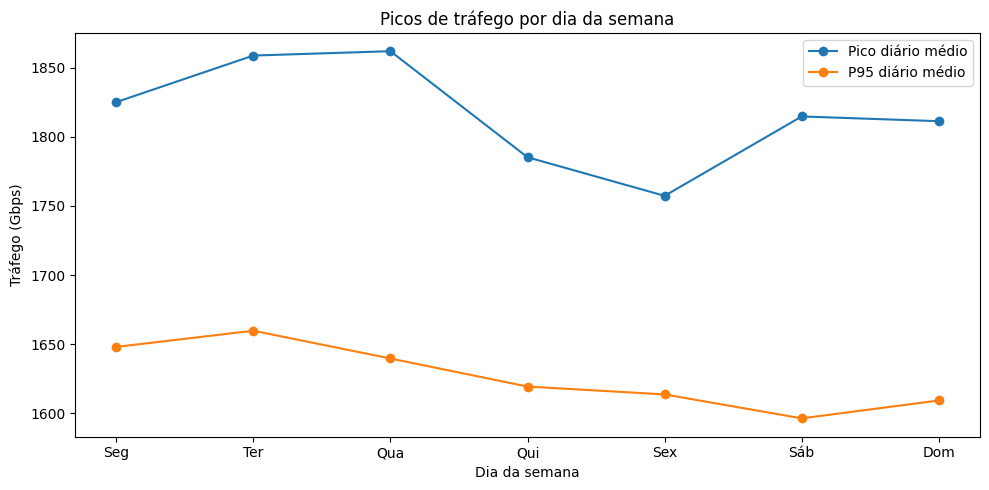

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(resumo_weekday_picos["weekday"], resumo_weekday_picos["media_pico_max_gbps"], marker="o", label="Pico diário médio")
plt.plot(resumo_weekday_picos["weekday"], resumo_weekday_picos["media_pico_p95_gbps"], marker="o", label="P95 diário médio")
plt.xticks(range(7), [mapa_dias[i] for i in range(7)])
plt.xlabel("Dia da semana")
plt.ylabel("Tráfego (Gbps)")
plt.title("Picos de tráfego por dia da semana")
plt.legend()
plt.tight_layout()
plt.show()

## 27. Variação intra semana

In [27]:
mapa_dias = {
    0: "Seg",
    1: "Ter",
    2: "Qua",
    3: "Qui",
    4: "Sex",
    5: "Sáb",
    6: "Dom"
}

periodos = [(2008, 2012), (2013, 2017), (2018, 2022), (2023, 2026)]

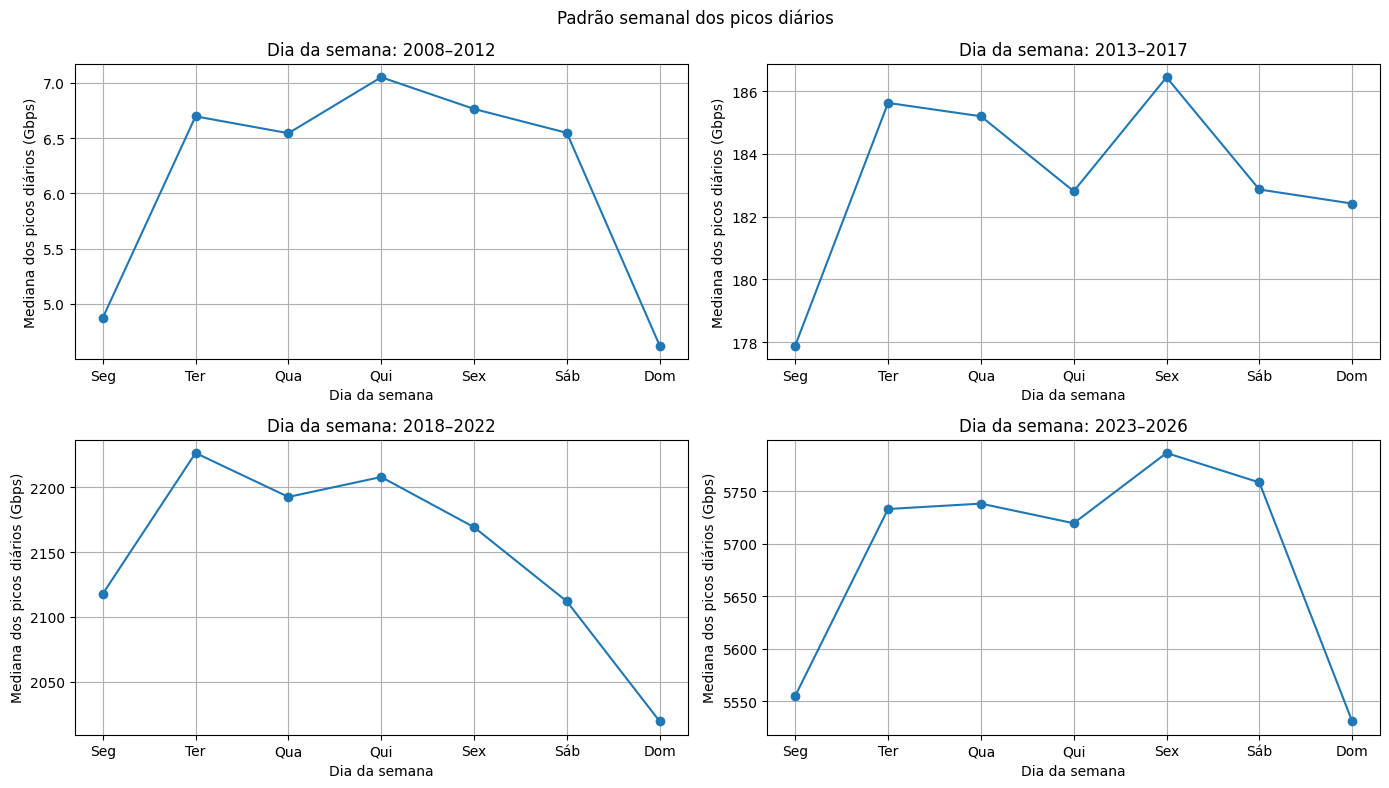

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()

for ax, bloco in zip(axes, periodos):
    df_temp = picos_diarios[
        (picos_diarios["ano"] >= bloco[0]) &
        (picos_diarios["ano"] <= bloco[1])
    ]

    resumo_weekday_pico = (
        df_temp
        .groupby("weekday")["pico_max_gbps"]
        .median()
        .reset_index(name="mediana_pico_max_gbps")
    )

    ax.plot(
        resumo_weekday_pico["weekday"],
        resumo_weekday_pico["mediana_pico_max_gbps"],
        marker="o"
    )

    ax.set_xticks(range(7))
    ax.set_xticklabels([mapa_dias[i] for i in range(7)])
    ax.set_title(f"Dia da semana: {bloco[0]}–{bloco[1]}")
    ax.set_xlabel("Dia da semana")
    ax.set_ylabel("Mediana dos picos diários (Gbps)")
    ax.grid(True)

plt.suptitle("Padrão semanal dos picos diários")
plt.tight_layout()
plt.show()

2008–2012
Segunda e domingo apresentam os menores picos.
O maior pico típico ocorre na quinta-feira.
Entre terça e sábado as diferenças são pequenas (aproximadamente entre 6,5 e 7,0 Gbps).

Isso sugere que, nos primeiros anos da série, os maiores picos concentravam-se nos dias úteis, enquanto domingo apresentava menor demanda máxima.

2013–2017

O padrão torna-se ainda mais uniforme.

Segunda continua sendo o dia com menor pico.
Sexta apresenta o maior pico.
Os demais dias ficam muito próximos (diferença inferior a 5 Gbps em torno de uma mediana de ~183 Gbps).

Na prática, os picos máximos tornam-se bastante semelhantes entre os dias da semana.

2018–2022

É o período em que aparece um padrão mais claro.

Terça-feira apresenta a maior mediana dos picos.
Domingo apresenta a menor.
A partir de quinta observa-se uma redução gradual até domingo.

Ou seja, diferentemente do tráfego médio, aqui os maiores picos continuam concentrados no meio da semana.

2023–2026

O comportamento permanece semelhante.

Sexta-feira concentra os maiores picos.
Domingo continua apresentando os menores.
Segunda também permanece abaixo dos dias centrais da semana.

Novamente, o perfil é relativamente estável ao longo da semana.

Comparando com o tráfego médio

Os gráficos de tráfego médio sugeriam uma mudança do dia de maior utilização ao longo do tempo (inclusive com domingo aparecendo como maior média no período mais recente).

Já os gráficos de picos diários contam uma história diferente:

os maiores picos continuam ocorrendo predominantemente em dias úteis;
domingo permanece sistematicamente entre os menores valores em praticamente todos os períodos.

Ou seja:

O dia em que a rede transporta mais tráfego, em média, não é necessariamente o dia em que ocorrem os maiores picos instantâneos.

## 28. Variação intra-dia

In [ ]:
# Preparação das variáveis horárias

df_intradia = df_filtrado.copy()

df_intradia["hora"] = df_intradia["datahora"].dt.hour
df_intradia["ano"] = df_intradia["datahora"].dt.year

# Perfil horário do tráfego para cada ano
perfil_horario_ano = (
    df_intradia
    .groupby(["ano", "hora"])["total_gbps"]
    .agg(
        media_gbps="mean",
        p95_gbps=lambda x: x.quantile(0.95)
    )
    .reset_index()
)


In [44]:
perfil_horario_ano["mediana_anual"] = (
    perfil_horario_ano
    .groupby("ano")["media_gbps"]
    .transform("median")
)

perfil_horario_ano["indice_horario"] = (
    perfil_horario_ano["media_gbps"] /
    perfil_horario_ano["mediana_anual"]
)

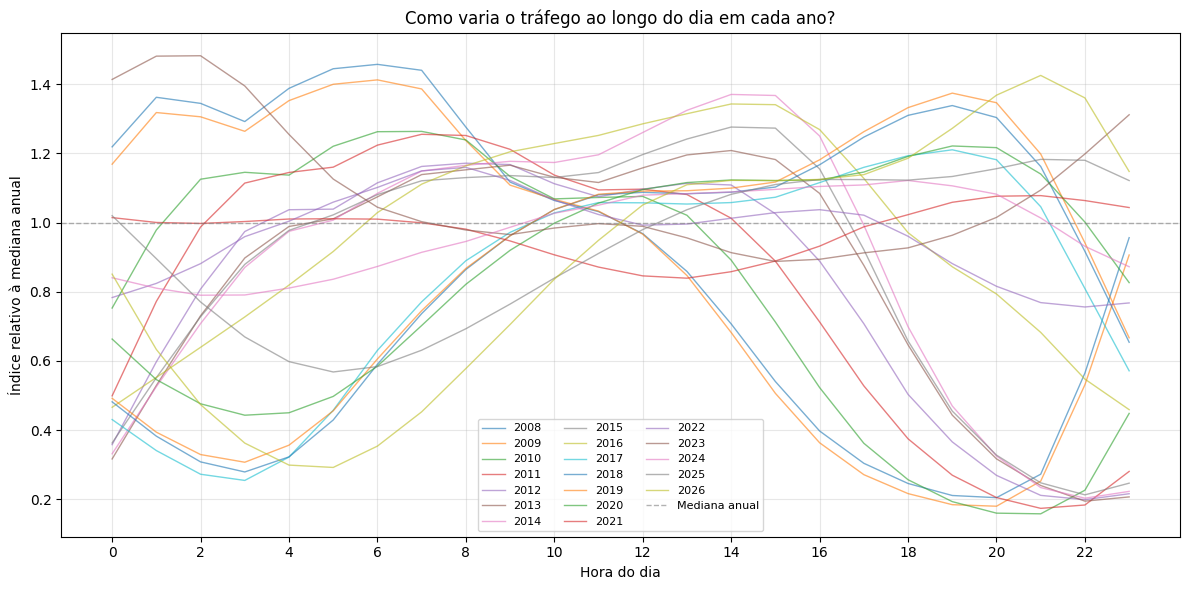

In [48]:
plt.figure(figsize=(12, 6))

for ano in sorted(perfil_horario_ano["ano"].unique()):
    df_temp = perfil_horario_ano[
        perfil_horario_ano["ano"] == ano
    ]

    plt.plot(
        df_temp["hora"],
        df_temp["indice_horario"],
        linewidth=1,
        alpha=0.6,
        label=str(ano)
    )

plt.xlabel("Hora do dia")
plt.ylabel("Índice relativo à mediana anual")
plt.title("Como varia o tráfego ao longo do dia em cada ano?")
plt.xticks(range(0, 24, 2))
plt.axhline(
    1,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.6,
    label="Mediana anual"
)
plt.grid(alpha=0.3)
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

In [46]:
perfil_horario_ano["mediana_p95_anual"] = (
    perfil_horario_ano
    .groupby("ano")["p95_gbps"]
    .transform("median")
)

perfil_horario_ano["indice_p95"] = (
    perfil_horario_ano["p95_gbps"] /
    perfil_horario_ano["mediana_p95_anual"]
)

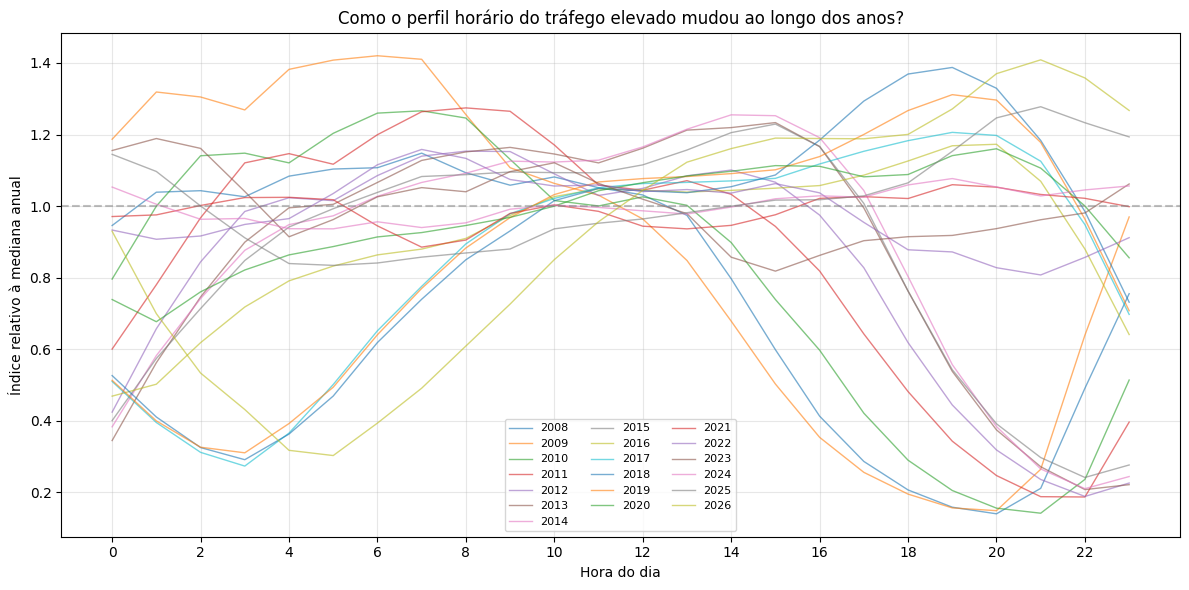

In [47]:
plt.figure(figsize=(12, 6))

for ano in sorted(perfil_horario_ano["ano"].unique()):
    df_temp = perfil_horario_ano[
        perfil_horario_ano["ano"] == ano
    ]

    plt.plot(
        df_temp["hora"],
        df_temp["indice_p95"],
        linewidth=1,
        alpha=0.6,
        label=str(ano)
    )

plt.xlabel("Hora do dia")
plt.ylabel("Índice relativo à mediana anual")
plt.title("Como o perfil horário do tráfego elevado mudou ao longo dos anos?")
plt.xticks(range(0, 24, 2))
plt.axhline(1, color="gray", linestyle="--", alpha=0.5)
plt.grid(alpha=0.3)
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()